# Results Loader and Plots Comparison for all Models

In [1]:
from pathlib import Path

import pandas as pd

from config.config import Config
from src.data import time_series_split
from src.plots import plot_forecast_diagnostics, plot_forecast_overlay, plot_return_overlay, plot_test_overlay, plot_val_overlay
from src.utils import load_results_from_dir, results_to_df, set_seed

In [2]:
cfg = Config.load()
SEED = cfg.runtime.seed
HORIZON = cfg.runtime.horizon
rng = set_seed(SEED)

OUT_DIR = Path(cfg.data.processed_dir)
FIG_DIR = Path(cfg.data.fig_dir)

2025-09-13 16:21:44,747 - INFO - src.utils - Global random seed set to 42


In [3]:
results = load_results_from_dir(OUT_DIR)
len(results), [r["kind"] for r in results]

(4, ['cnn', 'linreg', 'linreg_wo_sent', 'lstm'])

In [4]:
df_full = pd.read_csv(Path(cfg.data.processed_dir) / "features_full.csv")
train, val, test, forecast = time_series_split(df_full, train_ratio=0.8, val_ratio=0.1, horizon=HORIZON)

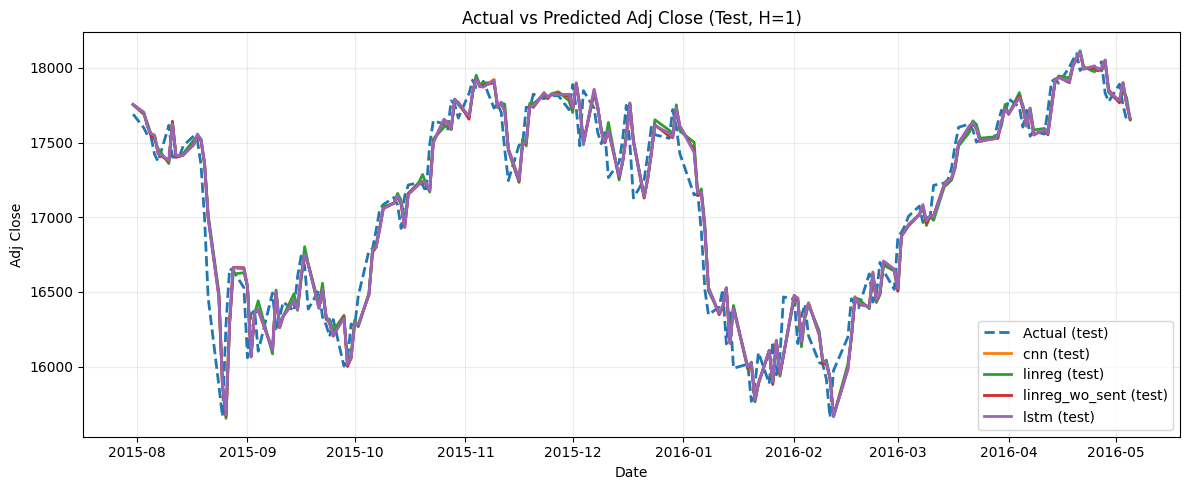

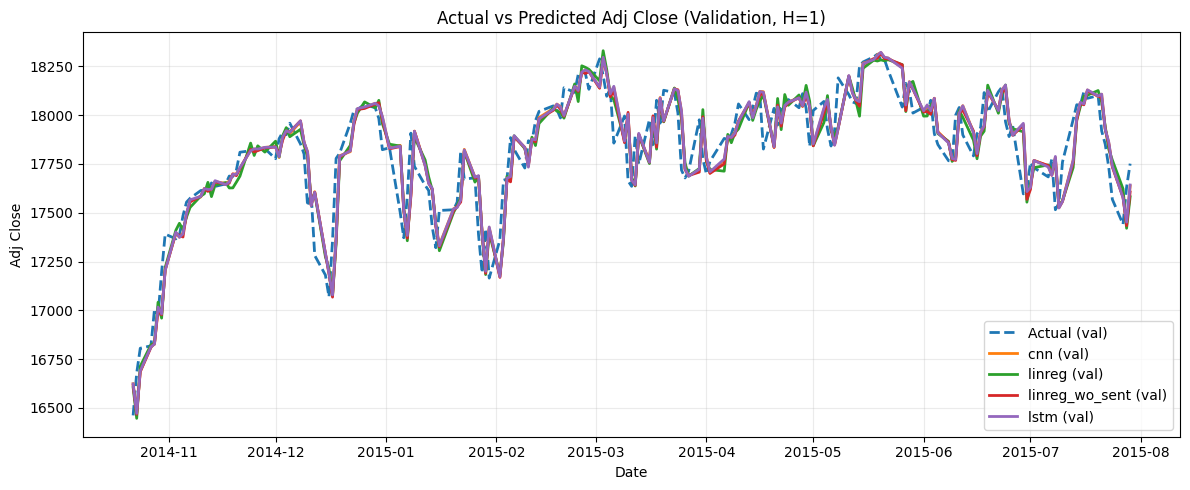

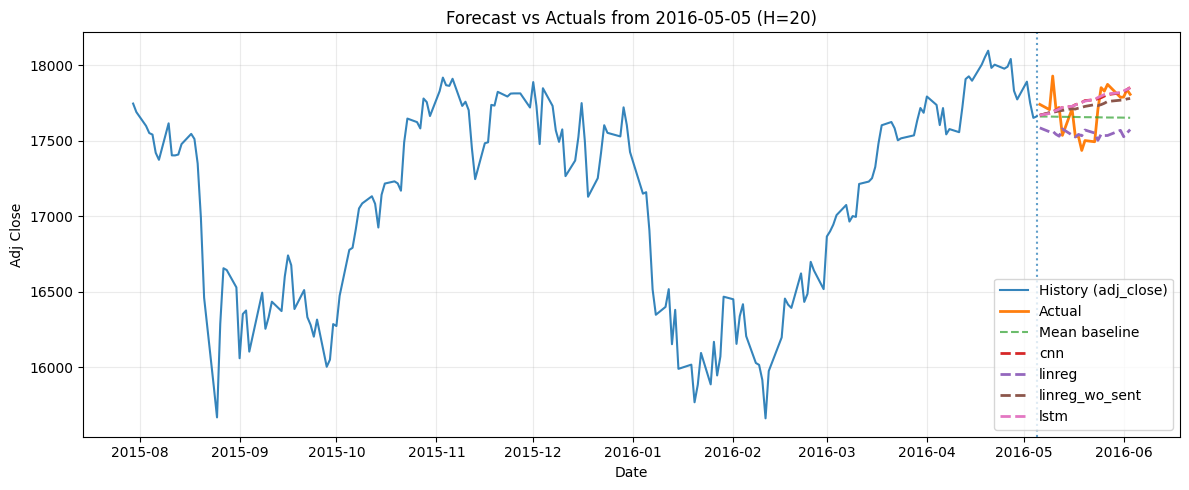

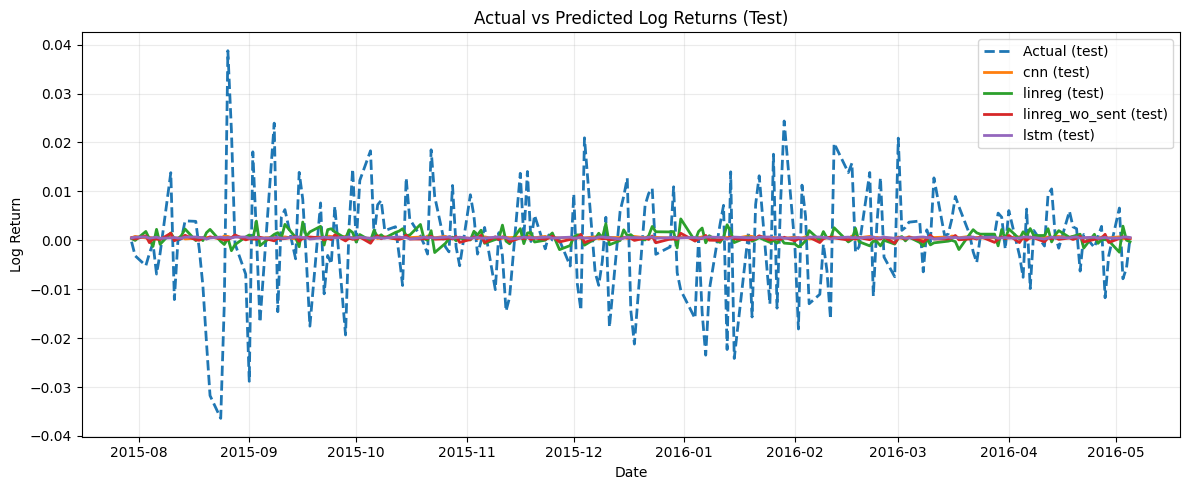

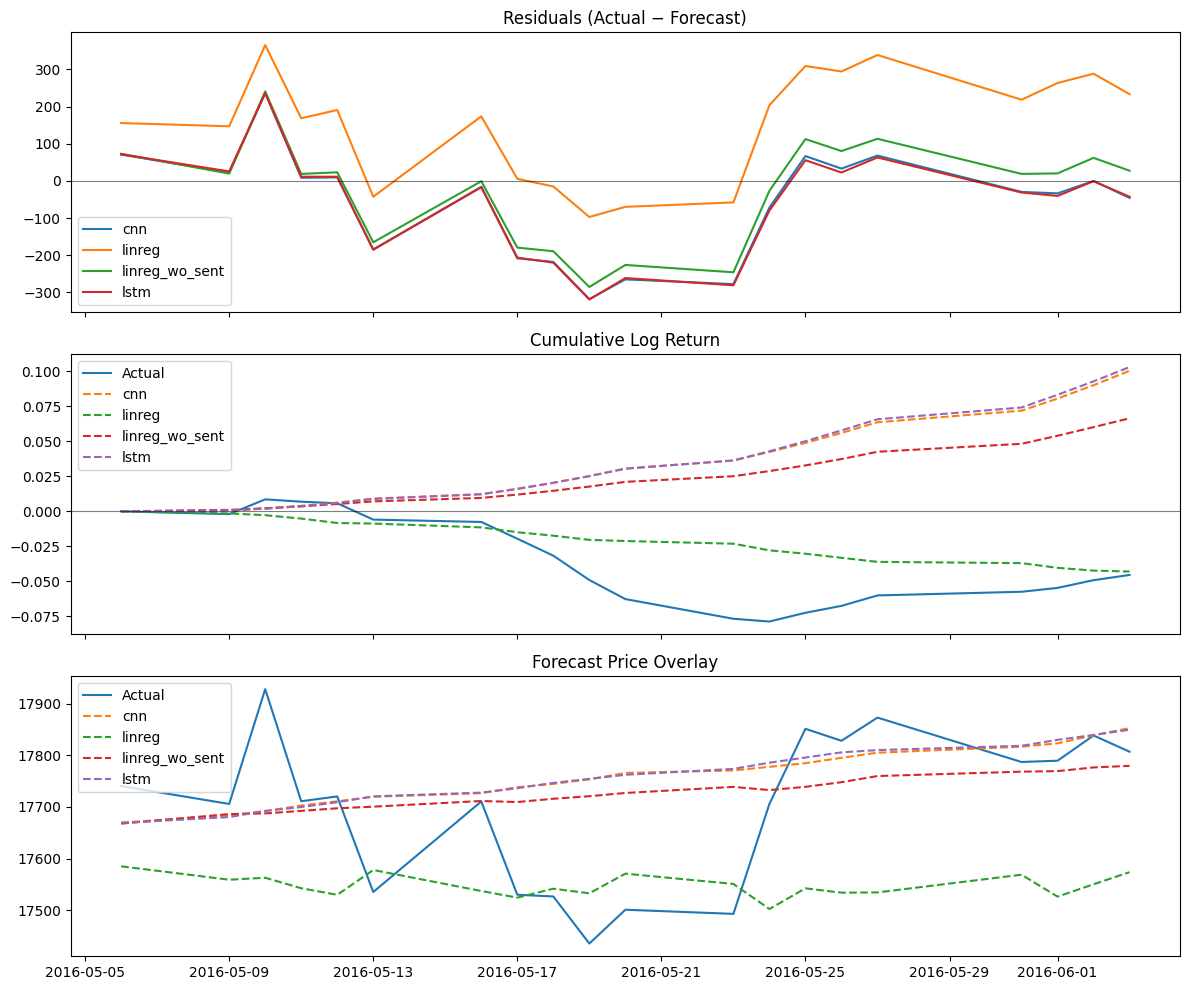

In [5]:
plot_test_overlay(test, results, Path(cfg.data.fig_dir) / "all_actual_vs_predicted_adj_close.png")
plot_val_overlay(val, results, Path(cfg.data.fig_dir) / "all_actual_vs_predicted_adj_close_val.png")
plot_forecast_overlay(test, forecast, results, Path(cfg.data.fig_dir) / "all_forecast.png")
plot_return_overlay(test, results, Path(cfg.data.fig_dir) / "all_returns.png", "test")
plot_forecast_diagnostics(forecast, test, results, Path(cfg.data.fig_dir) / "all_forecast_diagnostics.png")

In [6]:
params_summary = results_to_df(results, "best_params")
params_summary

,model,filters,kernel_size,dense_units,dropout,lr,epochs,batch_size,weight_decay,random_state,alpha,l1_ratio,max_iter,eta0,learning_rate,units,bidirectional
0,cnn,32.0,4.0,48.0,0.093128,0.000982,300.0,16.0,0.000012,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,linreg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42,0.009975,0.689704,2000.0,0.001011,constant,NaN,NaN
2,linreg_wo_sent,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42,0.009516,0.930052,2000.0,0.001160,constant,NaN,NaN
3,lstm,NaN,NaN,48.0,0.093513,0.001270,200.0,32.0,0.000016,42,NaN,NaN,NaN,NaN,NaN,32.0,False


In [8]:
metrics_summary = results_to_df(results, ["metrics", "test", "aggregate"])
metrics_summary

,model,mae,mse,rmse,r2,directional_accuracy
0,cnn,0.008156,0.000117,0.010839,-0.001304,0.529016
1,linreg,0.008249,0.000120,0.010933,-0.018749,0.511917
2,linreg_wo_sent,0.008176,0.000118,0.010871,-0.007238,0.516839
3,lstm,0.008156,0.000117,0.010839,-0.001328,0.529016
